In [14]:
#Importing dependencies
import numpy as np
import tensorflow as tf
import pandas as pd
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import RNN, SimpleRNN, LSTM
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.feature_extraction.text import CountVectorizer
import random
import matplotlib.pyplot as plt
%matplotlib inline
from mpl_toolkits import mplot3d
import warnings
warnings.filterwarnings("ignore")


# Bag of Words

## Sample Data

In [ ]:
corpus = ['king is a strong man','queen is a wise woman','boy is a young man',
          'girl is a young woman','prince is a young','prince will be strong',
          'princess is young','man is strong','woman is pretty', 'prince is a boy',
          'prince will be king', 'princess is a girl', 'princess will be queen']
print(corpus)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
DTM = cv.fit_transform(corpus)
DTM = pd.DataFrame(DTM.toarray(), columns=cv.get_feature_names_out())
DTM

## DTM on Review Data

In [ ]:
data = {'review': ['I loved this movie!', 'It was okay.', 'I hated it.', 'It was amazing!', 'I was disappointed.',
                   'It was a great experience.', 'I fell asleep during the movie.', 'It was a total waste of time.',
                   'I highly recommend this movie.', 'I would not recommend this movie.'],
       'sentiment': ['positive', 'neutral', 'negative', 'positive', 'negative',
                      'positive', 'negative', 'negative', 'positive', 'negative']}
df = pd.DataFrame(data)
df

In [ ]:
# Convert the input data into a DTM
cv = CountVectorizer()
dtm = cv.fit_transform(df['review'])
dtm = pd.DataFrame(dtm.toarray(), columns=cv.get_feature_names_out())
dtm["y_value"]=df["sentiment"]
# Print the DTM
dtm

# Word Embeddings

# LAB1: Simple Word Embeddings in TensorFlow

Remove stop words
In order for efficiency of creating word vector, we will remove commonly used words

In [1]:
corpus = ['king is a strong man','queen is a wise woman','boy is a young man',
          'girl is a young woman','prince is a young','prince will be strong',
          'princess is young','man is strong','woman is pretty', 'prince is a boy',
          'prince will be king', 'princess is a girl', 'princess will be queen']
print(corpus)

['king is a strong man', 'queen is a wise woman', 'boy is a young man', 'girl is a young woman', 'prince is a young', 'prince will be strong', 'princess is young', 'man is strong', 'woman is pretty', 'prince is a boy', 'prince will be king', 'princess is a girl', 'princess will be queen']


## Pre-processing

In [2]:
stop_words = ['is', 'a', 'the', 'will', 'be']
corpus_v1 = []
for sentence in corpus:
  sentence_v1 = []
  for word in sentence.split():
    if word not in stop_words:
      sentence_v1.append(word)
  corpus_v1.append(" ".join(sentence_v1))


print(corpus_v1)

all_words=  [word for text in corpus_v1 for word in text.split(' ')]
words=set(all_words)
#print(words)

word2int = {}

for i,word in enumerate(words):
    word2int[word] = i

sentences = []
for sentence in corpus_v1:
    sentences.append(sentence.split())

['king strong man', 'queen wise woman', 'boy young man', 'girl young woman', 'prince young', 'prince strong', 'princess young', 'man strong', 'woman pretty', 'prince boy', 'prince king', 'princess girl', 'princess queen']


## Data Preparation - Word to Context

In [4]:
import pandas as pd

WINDOW_SIZE = 2 #5-10

data = []
for sentence in sentences:
    for idx, word in enumerate(sentence):
        for neighbor in sentence[max(idx - WINDOW_SIZE, 0) : min(idx + WINDOW_SIZE, len(sentence)) + 1] :
            if neighbor != word:
                data.append([word, neighbor])

df = pd.DataFrame(data, columns = ['input', 'label'])
print(df)

       input     label
0       king    strong
1       king       man
2     strong      king
3     strong       man
4        man      king
5        man    strong
6      queen      wise
7      queen     woman
8       wise     queen
9       wise     woman
10     woman     queen
11     woman      wise
12       boy     young
13       boy       man
14     young       boy
15     young       man
16       man       boy
17       man     young
18      girl     young
19      girl     woman
20     young      girl
21     young     woman
22     woman      girl
23     woman     young
24    prince     young
25     young    prince
26    prince    strong
27    strong    prince
28  princess     young
29     young  princess
30       man    strong
31    strong       man
32     woman    pretty
33    pretty     woman
34    prince       boy
35       boy    prince
36    prince      king
37      king    prince
38  princess      girl
39      girl  princess
40  princess     queen
41     queen  princess


## One-Hot encoding

In [5]:
ONE_HOT_DIM = len(words)

In [7]:
import numpy as np
def to_one_hot_encoding(data_point_index):
    one_hot_encoding = np.zeros(ONE_HOT_DIM)
    one_hot_encoding[data_point_index] = 1
    return one_hot_encoding
X = [] # input word
Y = [] # target word

for x, y in zip(df['input'], df['label']):
    X.append(to_one_hot_encoding(word2int[ x ]))
    Y.append(to_one_hot_encoding(word2int[ y ]))

# convert them to numpy arrays
X_train = np.asarray(X)
Y_train = np.asarray(Y)
print(X_train.shape)
print(Y_train.shape)

(42, 12)
(42, 12)


In [9]:
X_train

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.,

In [12]:
Y_train

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0.,

## Model Building

In [15]:
model1 = Sequential()
model1.add(Dense(3, input_dim=X_train.shape[1], activation='sigmoid'))
model1.add(Dense(Y_train.shape[1] ,activation='softmax'))
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 3)                 39        
                                                                 
 dense_1 (Dense)             (None, 12)                48        
                                                                 
Total params: 87 (348.00 Byte)
Trainable params: 87 (348.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [16]:
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# Train model
history = model1.fit(X_train, Y_train, epochs=600, batch_size=4 , verbose=0 )

In [17]:
model1h = Sequential()
model1h.add(Dense(3, input_dim=X_train.shape[1], weights=model1.layers[0].get_weights()))
model1h.add(Activation('sigmoid'))
vectors_data = pd.DataFrame(model1h.predict(X_train))
vectors_data["word"]=df["input"]
vectors_data=vectors_data.drop_duplicates()
vectors_data.columns
print(vectors_data)

2/2 [==============================] - 0s 3ms/step
           0         1         2      word
0   0.380185  0.922941  0.102224      king
2   0.638262  0.894344  0.032006    strong
4   0.924786  0.952306  0.568110       man
6   0.937147  0.059021  0.895365     queen
8   0.129690  0.070899  0.890292      wise
10  0.112228  0.135135  0.806153     woman
12  0.100745  0.905716  0.175826       boy
14  0.179029  0.278775  0.218236     young
18  0.663111  0.317648  0.939308      girl
24  0.850473  0.904235  0.523999    prince
28  0.043520  0.477913  0.944641  princess
33  0.752456  0.063017  0.855293    pretty


## Final Word2Vec Data visualization

In [18]:
w2v_df=pd.DataFrame()
w2v_df["word"]=vectors_data["word"]
w2v_df["x1"]=vectors_data[0]
w2v_df["x2"]=vectors_data[1]
w2v_df["x3"]=vectors_data[2]
print(w2v_df)

        word        x1        x2        x3
0       king  0.380185  0.922941  0.102224
2     strong  0.638262  0.894344  0.032006
4        man  0.924786  0.952306  0.568110
6      queen  0.937147  0.059021  0.895365
8       wise  0.129690  0.070899  0.890292
10     woman  0.112228  0.135135  0.806153
12       boy  0.100745  0.905716  0.175826
14     young  0.179029  0.278775  0.218236
18      girl  0.663111  0.317648  0.939308
24    prince  0.850473  0.904235  0.523999
28  princess  0.043520  0.477913  0.944641
33    pretty  0.752456  0.063017  0.855293


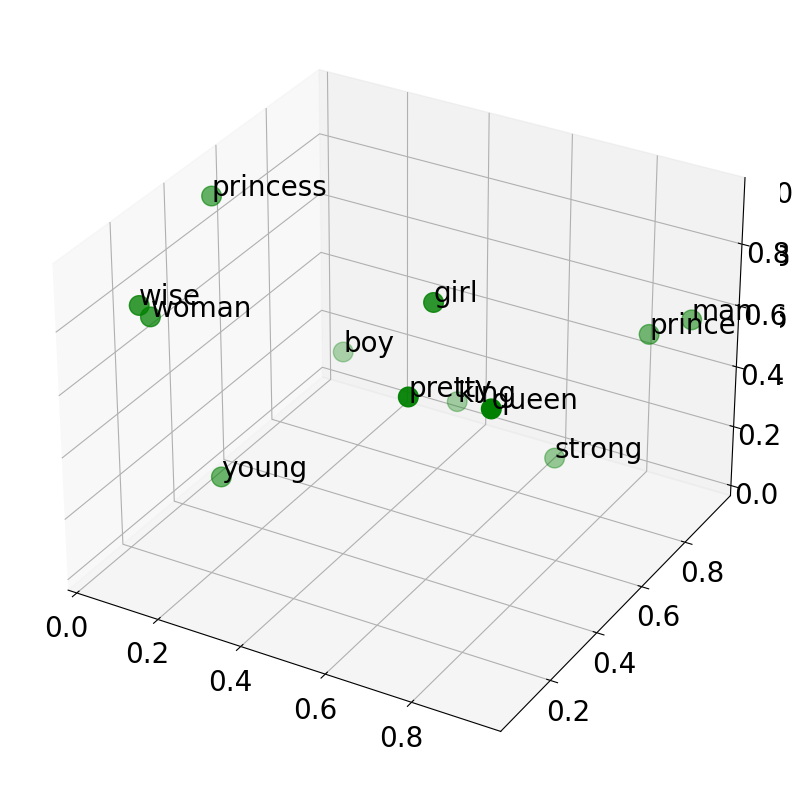

In [19]:
plt.rcParams.update({'font.size': 20})

fig = plt.figure(figsize=(15,10))
ax = plt.axes(projection='3d')
ax = plt.axes(projection='3d')

xdata = w2v_df["x1"]
ydata = w2v_df["x2"]
zdata = w2v_df["x3"]
names=w2v_df["word"]


ax.scatter3D(xdata, ydata, zdata, s=200 , c='green')
for names, x, y, z in zip(names, xdata, ydata, zdata):
    label = names
    ax.text(x, y, z, label )
plt.show()

# LAB2 : Word Embeddings example in Gensim

In [ ]:
!pip install gensim
!pip install google.cloud

In [ ]:
#import gzip
import gensim

In [ ]:
import urllib.request
#read cat image
urllib.request.urlretrieve("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/word2vec_data/King_queen_v1.txt", "King_queen_v1.txt")
data_file="King_queen_v1.txt"

In [ ]:
def read_input(input_file):

    with open (input_file, 'rb') as f:
        for i, line in enumerate (f):

            if (i%2==0):
                print("read {0} lines".format (i))
            # do some pre-processing and return a list of words for each review text
            yield gensim.utils.simple_preprocess (line)
# read the tokenized reviews into a list
# each review item becomes a series of words
# so this becomes a list of lists
documents = list (read_input (data_file))

In [ ]:
print(documents)

In [ ]:
from gensim.models import Word2Vec
model = Word2Vec(documents, min_count=1, vector_size=3, window = 2)
#size： size of word vector, hidden layer
#min-count：discard words that appear less than # times
#window：Context Window size

## Hyperparameters

### size
The hidden nodes size. The size of the dense vector to represent each token or word. If you have very limited data, then size should be a much smaller value. If you have lots of data, its good to experiment with various sizes.

### window
Context window size. The maximum distance between the target word and its neighboring word. If your neighbor's position is greater than the maximum window width to the left and the right, then, some neighbors are not considered as being related to the target word. In theory, a smaller window should give you terms that are more related. If you have lots of data, then the window size should not matter too much, as long as its a decent sized window.

### min_count
Minimium frequency count of words. The model would ignore words that do not statisfy the min_count. Extremely infrequent words are usually unimportant, so its best to get rid of those. Unless your dataset is really tiny, this does not really affect the model.

In [ ]:
vectors=model.wv[words]
print(vectors)

In [ ]:
# access vector for one word
print(model.wv['king'])
print(model.wv['man'])
print(model.wv['queen'])

In [ ]:
result=[print(word, model.wv[word]) for word in words]

In [ ]:
# save model
model.save(r"model1.bin")
# load model
new_model = Word2Vec.load(r"model1.bin")

# Additional Resources

## Pre trained model by google(3mn words)

In [ ]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

In [ ]:
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)
downloaded = drive.CreateFile({'id':"13e-z7BhTcm69qCjoFNehc6S0sc2qWod8"})
downloaded.GetContentFile("GoogleNews-vectors-negative300.zip")
!unzip GoogleNews-vectors-negative300.zip

#binfile- https://drive.google.com/file/d/1OfDK_9nUPYC1uCvscsr5z4cfBnWMrqX6/view?usp=sharing
#zipfile- https://drive.google.com/file/d/13e-z7BhTcm69qCjoFNehc6S0sc2qWod8/view?usp=sharing


In [ ]:
from gensim.models import KeyedVectors
# load the google word2vec model
filename="GoogleNews-vectors-negative300.bin"
model = KeyedVectors.load_word2vec_format(filename, binary=True)

In [ ]:
result = model.most_similar(positive=['congress', 'sonia'], topn=10)
print(result)

In [ ]:
# look up top 6 words similar to 'polite'
w1 = ["polite"]
model.wv.most_similar (positive=w1,topn=6)

In [ ]:
# look up top 6 words similar to 'france'
w1 = ["france"]
model.wv.most_similar (positive=w1,topn=6)

In [ ]:
w1 = ["india"]
model.wv.most_similar (positive=w1,topn=6)

In [ ]:
# look up top 6 words similar to 'shocked'
w1 = ["dhoni"]
model.wv.most_similar (positive=w1,topn=6)

In [ ]:
# similarity between two different words
model.wv.similarity(w1="dirty",w2="smelly")

In [ ]:
# similarity between two different words
model.wv.similarity(w1="dirty",w2="great")

In [ ]:
# similarity between two different words
model.wv.similarity(w1="dirty",w2="ugly")

In [ ]:
# Which one is the odd one out in this list?
model.wv.doesnt_match(["run","walk","france"])

In [ ]:
model.wv.doesnt_match(["run","india","france"])

In [ ]:
w1 = ["Nityananda"]
model.wv.most_similar (positive=w1,topn=10)

In [ ]:
w1 = ["chess"]
model.wv.most_similar (positive=w1,topn=6)

##Application of Word2Vec - Sentiment Analysis

[Word2_vec_Sentiment_Analysis code file](https://colab.research.google.com/drive/1666qEPApWzdw-efCu7JHhulF3MLRG2cw)